In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numpy import isin
from scipy.stats import linregress
import sys
import os
sys.path.insert(0, os.path.abspath('..')) 
from src.visualisation.plot_type_deviation import *
from src.visualisation.plot_type_order_deviation import *
from src.data_related.data_selector import *

# Loading the data_base. Minimal in this case as we are just focusing on total_stats.
df = pd.read_csv('../datasets/processed/pkdx_min.csv', index_col='id')

In [2]:
# I will start checking if typing has some roles on defining the BST of pokemon given their stage and category. As a first check, I will group pokemon by type, stage and category

mono = df[df['type_2'].isna()].groupby(['type_1', 'stage', 'category'])['total_stats'].agg(mean='mean', median= 'median', count= 'count')
dual_t1 = df[df['type_2'].notna()].groupby(['type_1', 'stage', 'category'])['total_stats'].agg(mean= 'mean', median='median', count='count')
dual_t2 = df[df['type_2'].notna()].groupby(['type_2', 'stage', 'category'])['total_stats'].agg(mean= 'mean', median='median', count='count')

# OBS! Notation below does not work because previous df have multiindex. Best is to make flat. Reset_index()
#dual_t1[dual_t1['stage']=='s2c2']

flat_mono = mono.reset_index()
flat_dual_t1 = dual_t1.reset_index()
flat_dual_t2 = dual_t2.reset_index()

In [3]:
# Create baselines. Basically this will find the median for a given stage and category.
regular = df[df['category'].isin(['regular'])]
legendary = df[df['category'].isin(['legendary'])]
regular_baseline = regular.groupby('stage')['total_stats'].median()
legendary_baseline = legendary['total_stats'].median()

# Calculate deviations for flat_mono
flat_mono['deviation'] = flat_mono['median'] - flat_mono['stage'].map(regular_baseline)
flat_mono['construction'] = 'mono'  # This will add an extra column and a tag to identify if the type construction of the pokemon (i.e. mono-type, type_1 or type_2)

# Calculate deviations for flat_dual_t1
flat_dual_t1['deviation'] = flat_dual_t1['median'] - flat_dual_t1['stage'].map(regular_baseline)
flat_dual_t1['construction'] = 'dual_t1' 

# Rename and calculate for flat_dual_t2
flat_dual_t2 = dual_t2.reset_index()
flat_dual_t2 = flat_dual_t2.rename(columns={'type_2': 'type_1'})
flat_dual_t2['deviation'] = flat_dual_t2['median'] - flat_dual_t2['stage'].map(regular_baseline)
flat_dual_t2['construction'] = 'dual_t2'

# Concatenate all three
flat_all = pd.concat([flat_mono, flat_dual_t1, flat_dual_t2], ignore_index=True)

Plot saved to: ../plots/type_dev_s2c2.png


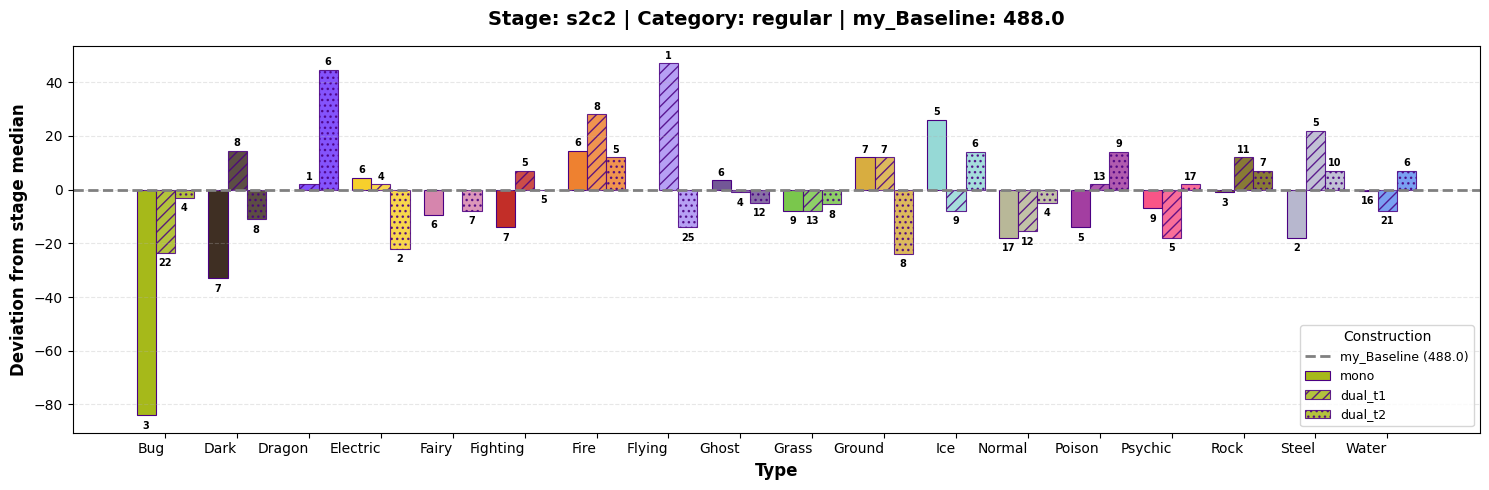

Plot saved to: ../plots/type_dev_s3c3.png


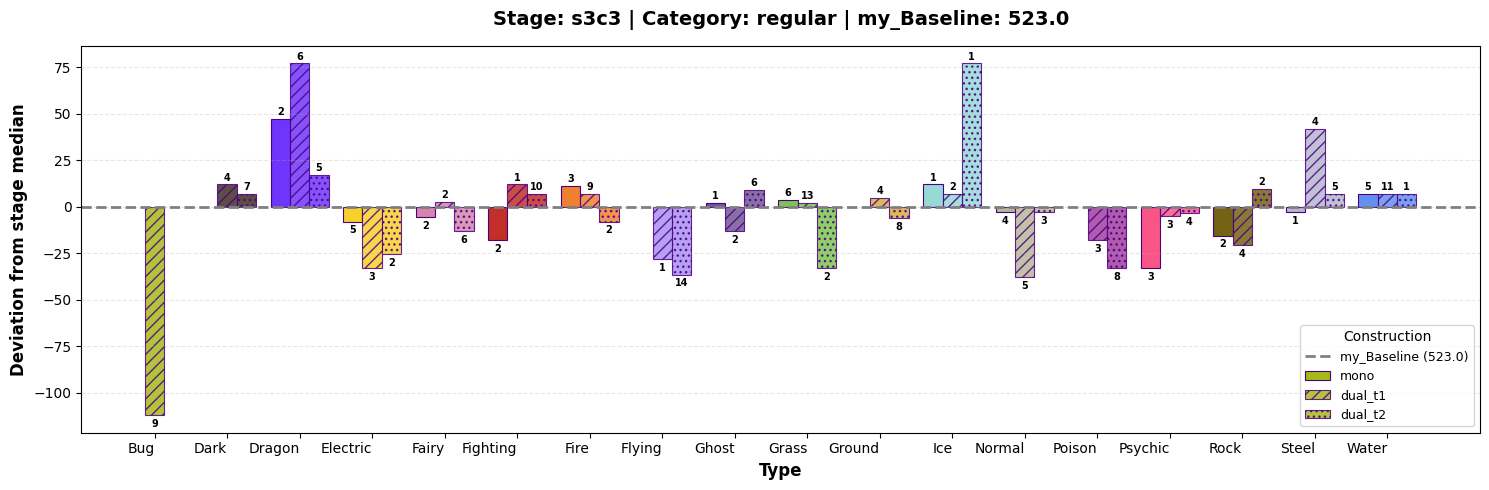

Plot saved to: ../plots/type_dev_single.png


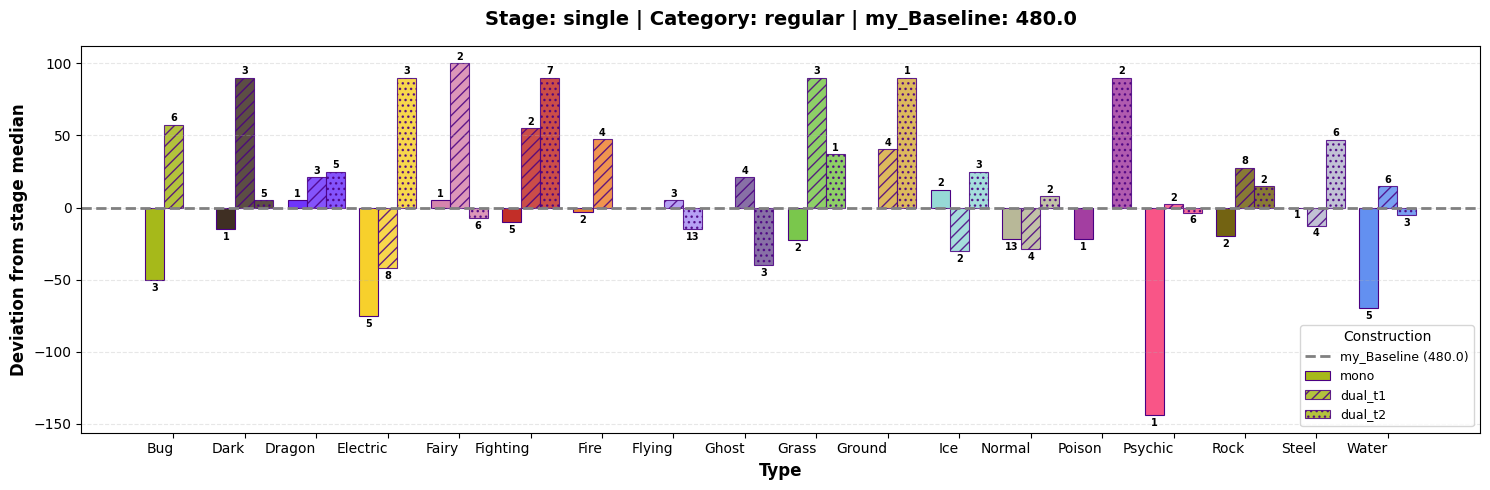

In [4]:
# With a more competitive aim, let us plot some of the distributions given the type construction.
# Insights can be read in the README.md document.

plot_type_deviations('s2c2', 'regular', regular_baseline, flat_all, save_path='../plots/type_dev_s2c2.png')
plot_type_deviations('s3c3', 'regular', regular_baseline, flat_all, save_path='../plots/type_dev_s3c3.png')
plot_type_deviations('single', 'regular', regular_baseline, flat_all, save_path='../plots/type_dev_single.png')

In [5]:
# Let us now go to extract information on the type ordering. We want to see if order matters when talking about types.


results = compare_type_ordering(stage='s3c3', baseline=regular_baseline, df=flat_all, min_count=3)
results.head(100)


,type_2,dual_t1_dev,dual_t2_dev,n_t1,n_t2,difference,abs_diff,baseline
type_1,,,,,,,,
dragon,dragon,77.0,17.0,6,5,60.0,60.0,523.0
normal,normal,-38.0,-3.0,5,3,-35.0,35.0,523.0
steel,steel,42.0,7.0,4,5,35.0,35.0,523.0
poison,poison,-18.0,-33.0,3,8,15.0,15.0,523.0
ground,ground,4.5,-6.0,4,8,10.5,10.5,523.0
dark,dark,12.0,7.0,4,7,5.0,5.0,523.0
psychic,psychic,-5.0,-3.5,3,4,-1.5,1.5,523.0


In [6]:
# This is where things get interesting. Let AI define a function to plot how each type, depending on the ordering and filtering throw a minimal counting of repeated type combinations, deviates from a baseline, depending if the specific type is type_1 or type_2. 

Plot saved to: ../plots/type_order_s1c2.png


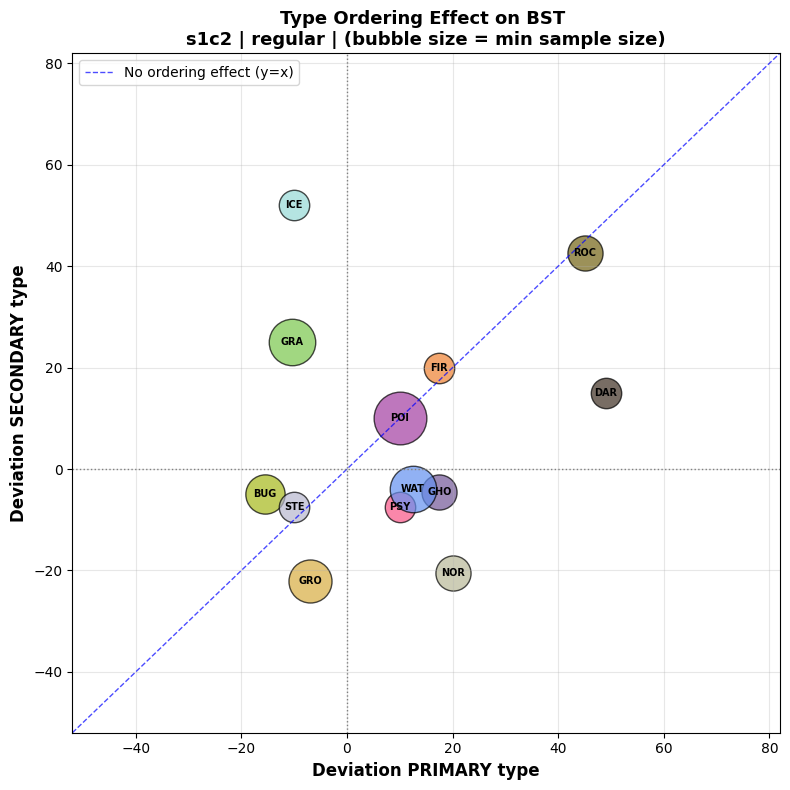

Plot saved to: ../plots/type_order_s2c2.png


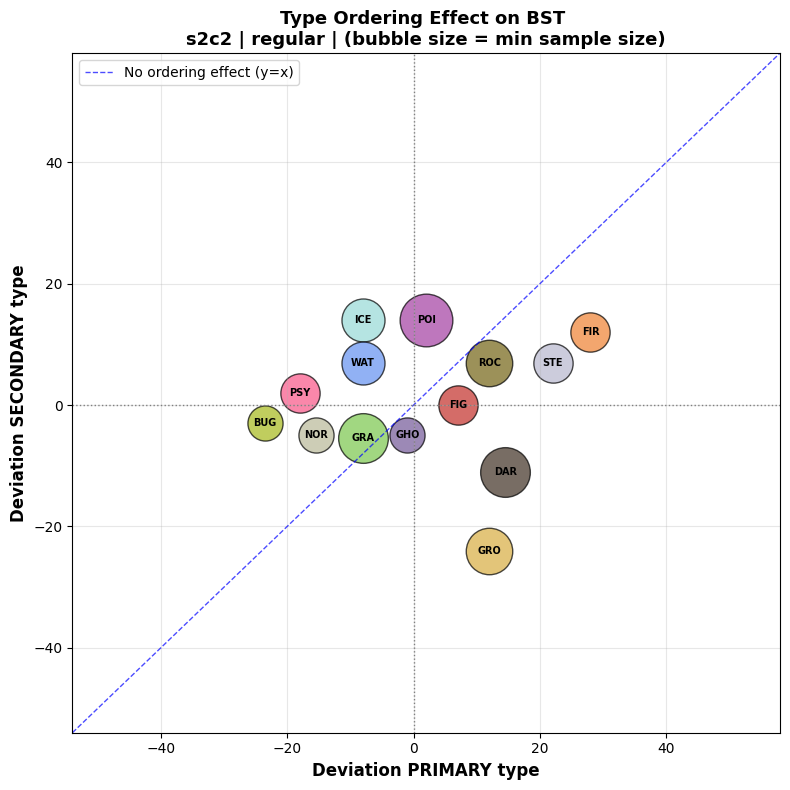

Plot saved to: ../plots/type_order_s3c3.png


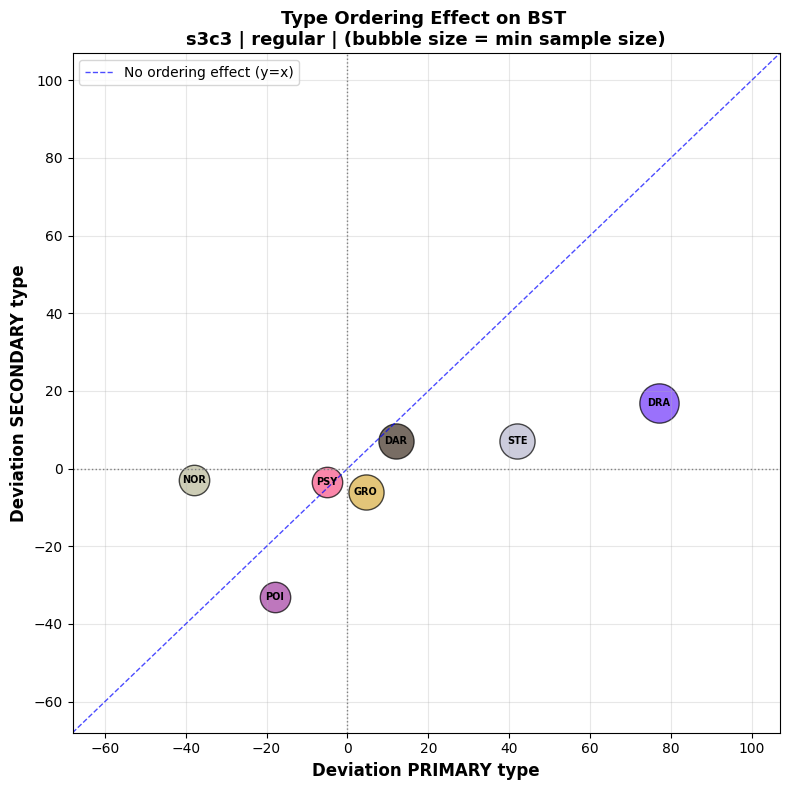

Plot saved to: ../plots/type_order_single.png


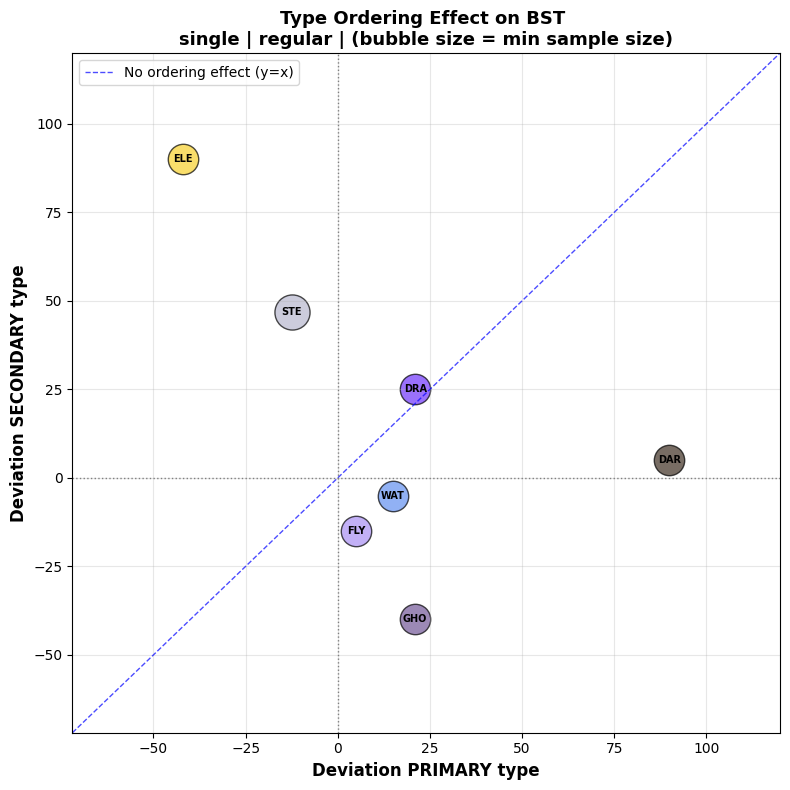

In [7]:
stages = ['s1c2', 's2c2', 's3c3', 'single']

for stage in stages:
    plot_type_order_deviation(stage, regular_baseline, flat_all, min_count=3, category='regular', save_path=f'../plots/type_order_{stage}.png')

